In [1]:
# Investigating the Model() and trace object, observed datasets, prior and posterior.

In [2]:
import pymc as pm
import pytensor
import numpy as np

from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

plt.style.use("ggplot")
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

In [3]:
# generate data
mu = 0
sigma = 1
obs = stats.norm.rvs(loc=mu, scale=sigma, size=100)

In [4]:
# model without observed

with pm.Model() as model:
    mu = pm.Uniform('mu', -5, 5)
    sigma = pm.Uniform('sigma', .001, 3)
    dist = pm.Normal('dist', mu=mu, sigma=sigma)

    step = pm.Metropolis()
    trace = pm.sample(2000, step=step, chains=2, return_inferencedata=False)

# the `return_inferencedata` argument returns an Arviz object (True, default) or a Multitrace object (False.)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [sigma]
>Metropolis: [dist]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<function matplotlib.pyplot.show(close=None, block=None)>

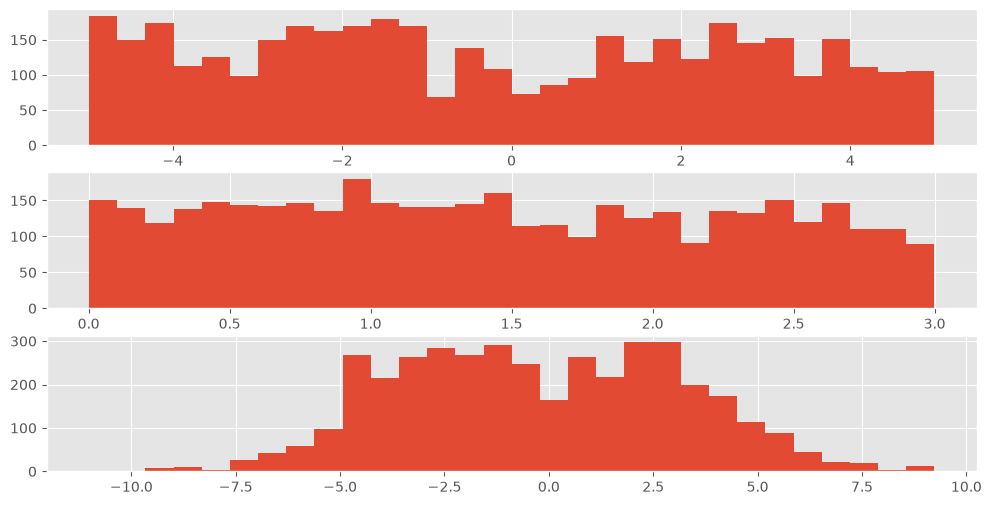

In [5]:
mu_samples = trace['mu']
sigma_samples = trace['sigma']
dist_samples = trace['dist']

figsize(12,6)

ax = plt.subplot(311)
plt.hist(mu_samples, bins=30)

ax = plt.subplot(312)
plt.hist(sigma_samples, bins=30)

ax = plt.subplot(313)
plt.hist(dist_samples, bins=30)

plt.show

# these are all just "priors" -- random samples from the prior distribution, no observed data included.


In [6]:
# model with observed

with pm.Model() as model:
    mu = pm.Uniform('mu', -5, 5)
    sigma = pm.Uniform('sigma', .01, 3)
    dist = pm.Normal('dist', mu=mu, sigma=sigma, observed=obs)

    step = pm.Metropolis()
    trace = pm.sample(2000, step=step, chains=2)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


<function matplotlib.pyplot.show(close=None, block=None)>

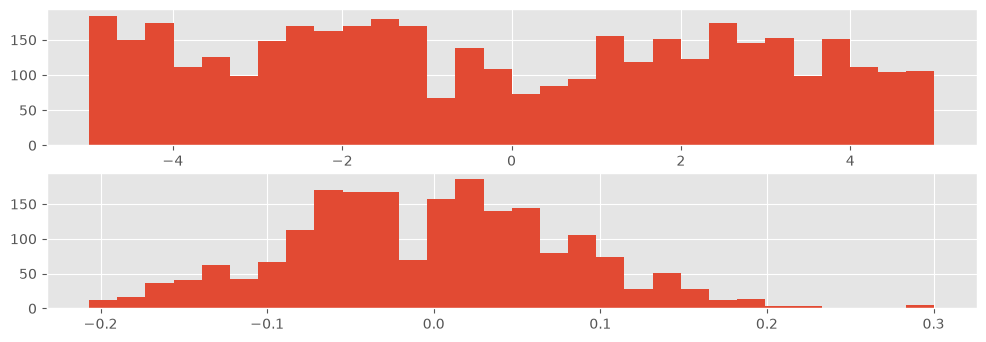

In [7]:
# mu - samples from uniform dist with and without observations provided
# i.e. the prior and the posterior
mu_samples_obs = np.concatenate(trace.posterior.mu.data[:,1000:])

figsize(12,6)
ax = plt.subplot(311)
plt.hist(mu_samples, bins=30)

ax = plt.subplot(312)
plt.hist(mu_samples_obs, bins=30)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

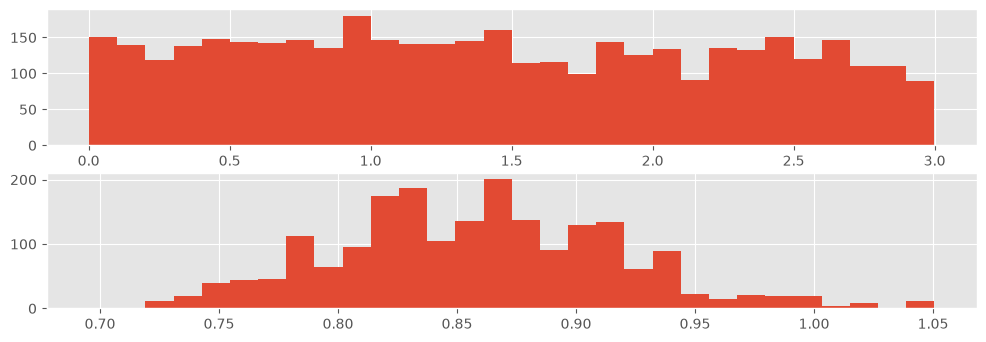

In [ ]:
# sigma - samples from uniform dist with and without observations provided
# i.e. the prior and the posterior
sigma_samples_obs = np.concatenate(trace.posterior.sigma.data[:,1000:])

figsize(12,6)
ax = plt.subplot(311)
plt.hist(sigma_samples, bins=30)

ax = plt.subplot(312)
plt.hist(sigma_samples_obs, bins=30)
plt.show

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

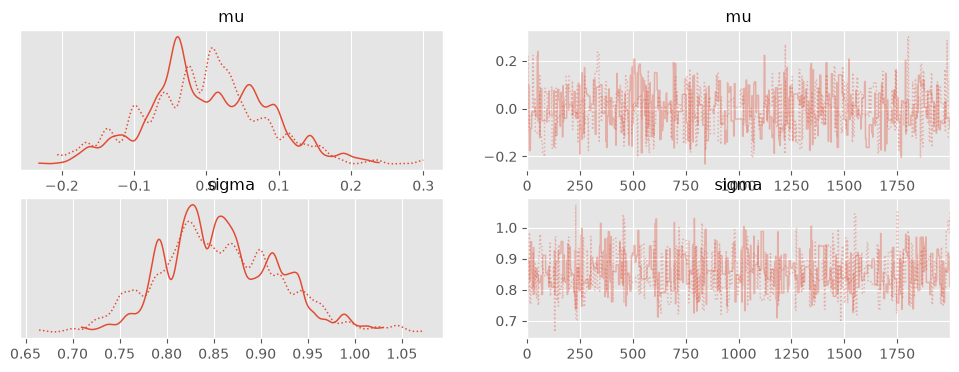

In [9]:
az.plot_trace(trace)

In [10]:
# examine the structure of the Arviz object
trace.__dict__

{'_groups': ['posterior', 'sample_stats', 'observed_data'],
 '_groups_warmup': [],
 '_attrs': {},
 'posterior': <xarray.Dataset> Size: 80kB
 Dimensions:  (chain: 2, draw: 2000)
 Coordinates:
   * chain    (chain) int64 16B 0 1
   * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
 Data variables:
     mu       (chain, draw) float64 32kB 0.09709 0.09709 ... -0.1238 -0.1238
     sigma    (chain, draw) float64 32kB 0.8925 0.8925 0.8925 ... 0.9836 1.051
 Attributes:
     created_at:                 2026-07-10T16:31:12.145717+00:00
     arviz_version:              0.23.4
     inference_library:          pymc
     inference_library_version:  5.26.1
     sampling_time:              0.2258141040802002
     tuning_steps:               1000,
 'sample_stats': <xarray.Dataset> Size: 208kB
 Dimensions:         (chain: 2, draw: 2000, accepted_dim_0: 2, scaling_dim_0: 2,
                      accept_dim_0: 2)
 Coordinates:
   * chain           (chain) int64 16B 0 1
   * draw

In [11]:
# the posterior samples for mu and sigma, by chain
trace['posterior']

<xarray.Dataset> Size: 80kB
Dimensions:  (chain: 2, draw: 2000)
Coordinates:
  * chain    (chain) int64 16B 0 1
  * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
Data variables:
    mu       (chain, draw) float64 32kB 0.09709 0.09709 ... -0.1238 -0.1238
    sigma    (chain, draw) float64 32kB 0.8925 0.8925 0.8925 ... 0.9836 1.051
Attributes:
    created_at:                 2026-07-10T16:31:12.145717+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              0.2258141040802002
    tuning_steps:               1000

In [12]:
# the 'sample_stats' .. not sure, "accept, accepted, scaling"?
trace['sample_stats']

<xarray.Dataset> Size: 208kB
Dimensions:         (chain: 2, draw: 2000, accepted_dim_0: 2, scaling_dim_0: 2,
                     accept_dim_0: 2)
Coordinates:
  * chain           (chain) int64 16B 0 1
  * draw            (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
  * accepted_dim_0  (accepted_dim_0) int64 16B 0 1
  * scaling_dim_0   (scaling_dim_0) int64 16B 0 1
  * accept_dim_0    (accept_dim_0) int64 16B 0 1
Data variables:
    accepted        (chain, draw, accepted_dim_0) float64 64kB 0.0 0.0 ... 1.0
    scaling         (chain, draw, scaling_dim_0) float64 64kB 0.2152 ... 0.6561
    accept          (chain, draw, accept_dim_0) float64 64kB 3.711e-15 ... 0....
Attributes:
    created_at:                 2026-07-10T16:31:12.149005+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              0.2258141040802002
    tuning_steps:               1000

In [13]:
# a copy of the observed data
trace['observed_data']

<xarray.Dataset> Size: 2kB
Dimensions:     (dist_dim_0: 100)
Coordinates:
  * dist_dim_0  (dist_dim_0) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
Data variables:
    dist        (dist_dim_0) float64 800B -0.7854 0.6893 ... -0.4163 0.8744
Attributes:
    created_at:                 2026-07-10T16:31:12.149974+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.26.1

In [ ]:
# how to plot the prior and posterior distribution?

# the trace object doesn't create a posterior distribution itself, just the variables that were sampled .. 
# so we need to run a Posterior Predictive Check (PPC) with the sample_posterior_predictive() function inside the Model()
# also use sample_prior_predictive to get samples of the prior distribution to compare.

# https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample_posterior_predictive.html
# https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample_prior_predictive.html

# these functions take the sampled mu & sigma pairs and generates new samples.  (I assume it uses the distribution specificed in `observed`) and then plot both with Arviz function az.plot_ppc(ppc, num_pp_samples)

# https://python.arviz.org/en/v0.21.0/api/generated/arviz.plot_ppc.html


In [19]:
# model with observed data and posterior predictive check (ppc)

with pm.Model() as model:
    mu = pm.Uniform('mu', -5, 5)
    sigma = pm.Uniform('sigma', .01, 3)
    observed = pm.Normal('observed', mu=mu, sigma=sigma, observed=obs)

    step = pm.Metropolis()
    trace = pm.sample(2000, step=step, chains=2)

    prior = pm.sample_prior_predictive(samples=100)
    ppc = pm.sample_posterior_predictive(trace)


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [mu, observed, sigma]
Sampling: [observed]


Output()

In [ ]:
trace.__dict__

{'_groups': ['posterior', 'sample_stats', 'observed_data'],
 '_groups_warmup': [],
 '_attrs': {},
 'posterior': <xarray.Dataset> Size: 80kB
 Dimensions:  (chain: 2, draw: 2000)
 Coordinates:
   * chain    (chain) int64 16B 0 1
   * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
 Data variables:
     mu       (chain, draw) float64 32kB -0.04631 -0.04631 ... -0.07867 -0.07867
     sigma    (chain, draw) float64 32kB 0.886 0.886 0.8203 ... 0.8758 0.8758
 Attributes:
     created_at:                 2026-07-10T16:36:03.434048+00:00
     arviz_version:              0.23.4
     inference_library:          pymc
     inference_library_version:  5.26.1
     sampling_time:              0.24910593032836914
     tuning_steps:               1000,
 'sample_stats': <xarray.Dataset> Size: 208kB
 Dimensions:         (chain: 2, draw: 2000, accepted_dim_0: 2, scaling_dim_0: 2,
                      accept_dim_0: 2)
 Coordinates:
   * chain           (chain) int64 16B 0 1
   * 

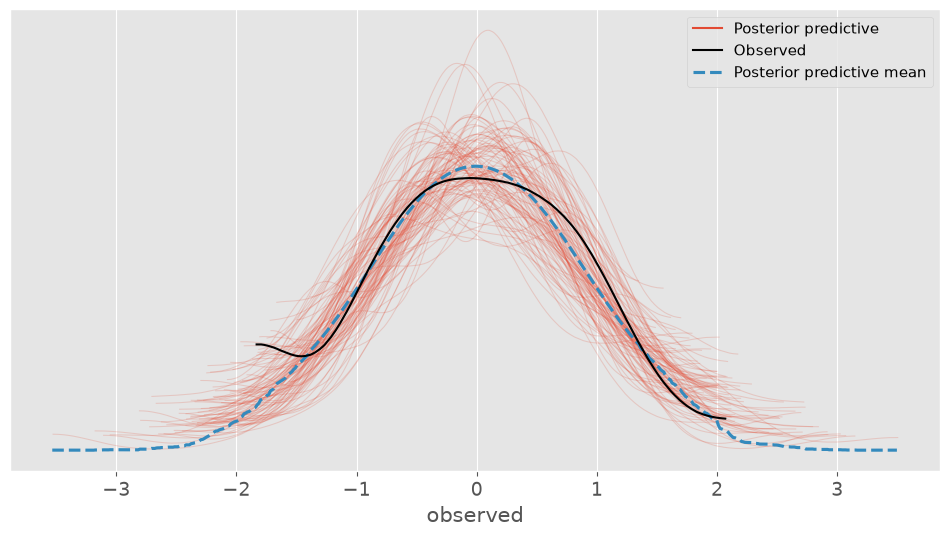

In [25]:
az.plot_ppc(ppc, num_pp_samples=100)
plt.show()

<Axes: xlabel='observed'>

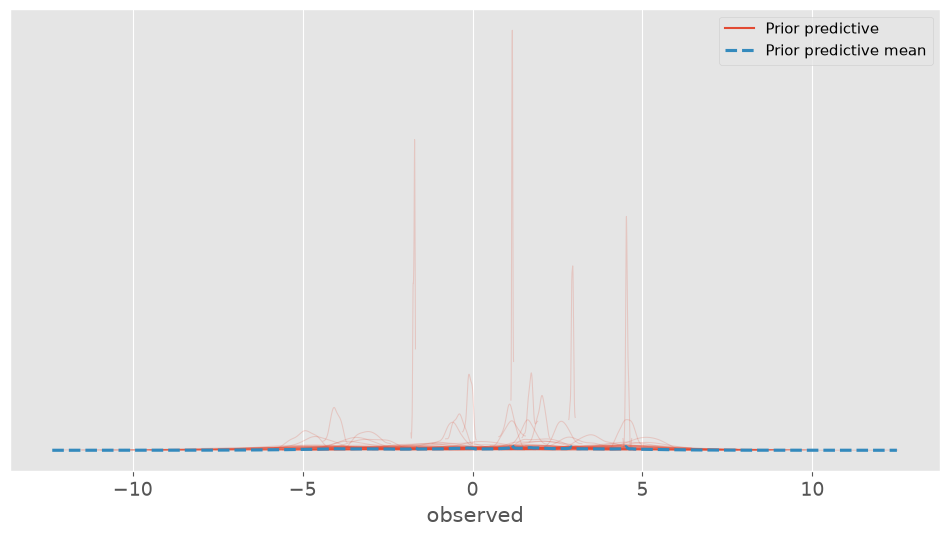

In [ ]:
# 
az.plot_ppc(prior, group="prior", num_pp_samples=100)